In [ ]:
pip install opencv-python matplotlib numpy

Original image shape: (350, 642, 3)


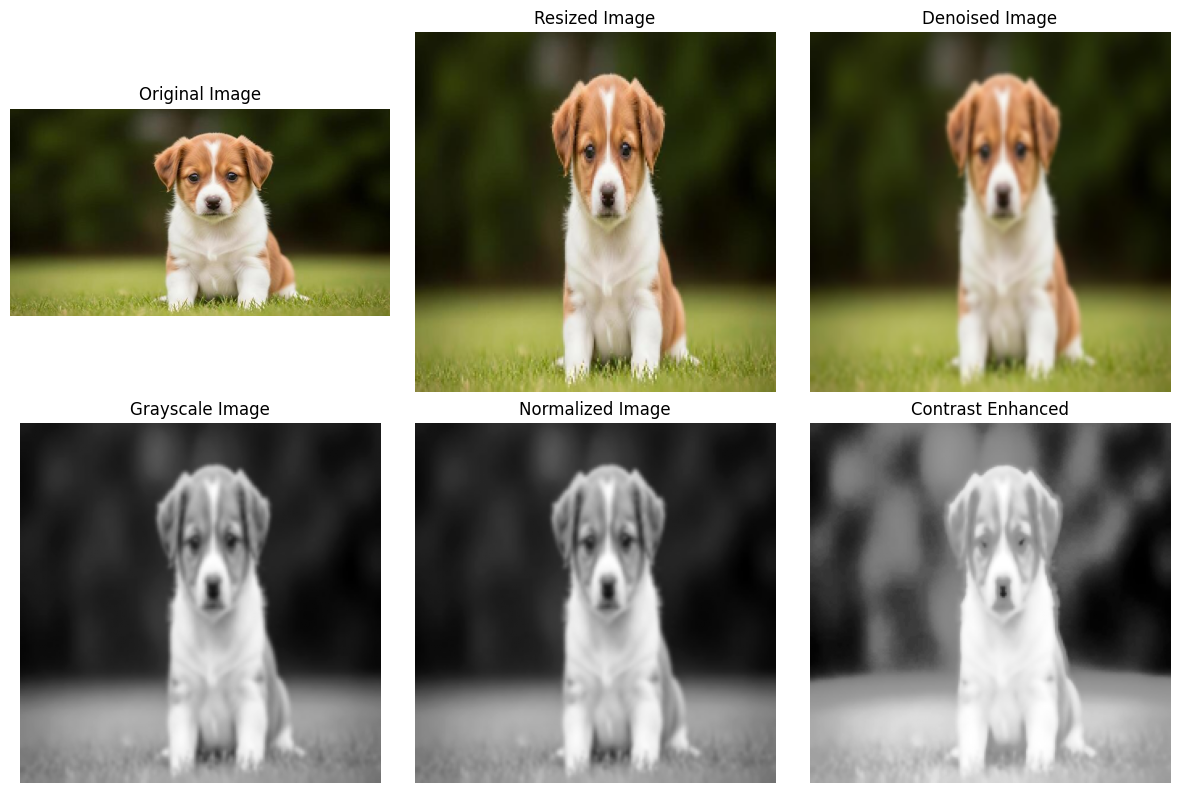

Preprocessing completed!
Saved as: preprocessed_dog.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# STEP 1: Read the image
# ---------------------------------------
image = cv2.imread("/content/dog.jpg")

# Check whether image is loaded
if image is None:
    print("Error: Image not found")
    exit()

print("Original image shape:", image.shape)


# ---------------------------------------
# STEP 2: Convert BGR to RGB
# ---------------------------------------
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# ---------------------------------------
# STEP 3: Resize the image
# ---------------------------------------
# Common size for deep learning models
resized = cv2.resize(image_rgb, (224, 224))


# ---------------------------------------
# STEP 4: Noise removal
# ---------------------------------------
# Gaussian Blur reduces small unwanted noise
denoised = cv2.GaussianBlur(resized, (5, 5), 0)


# ---------------------------------------
# STEP 5: Convert image to grayscale
# ---------------------------------------
gray = cv2.cvtColor(denoised, cv2.COLOR_RGB2GRAY)


# ---------------------------------------
# STEP 6: Normalize pixel values
# ---------------------------------------
# Converts pixel values from 0-255 to 0-1
normalized = gray / 255.0


# ---------------------------------------
# STEP 7: Histogram Equalization
# ---------------------------------------
# Improves contrast
equalized = cv2.equalizeHist(gray)


# ---------------------------------------
# STEP 8: Display results
# ---------------------------------------
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(resized)
plt.title("Resized Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(denoised)
plt.title("Denoised Image")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(normalized, cmap="gray")
plt.title("Normalized Image")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(equalized, cmap="gray")
plt.title("Contrast Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()


# ---------------------------------------
# STEP 9: Save preprocessed image
# ---------------------------------------
cv2.imwrite(
    "/mnt/data/preprocessed_dog.jpg",
    equalized
)

print("Preprocessing completed!")
print("Saved as: preprocessed_dog.jpg")